In [47]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tqdm as tqdm

### Loading Image and video


In [48]:
book_img = cv2.imread('assignment_2_materials/cv_cover.jpg', cv2.COLOR_BGR2GRAY)
video = cv2.VideoCapture('assignment_2_materials/book.mov')
success, frame = video.read()

if not success:
    print("Error: Could not read video.")
    exit()

video.release()
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

### SIFT detector


In [49]:
sift_detector=cv2.SIFT_create()

# Detect keypoints and descriptors
keypoints1, descriptors1 = sift_detector.detectAndCompute(book_img, None)
keypoints2, descriptors2 = sift_detector.detectAndCompute(gray_frame, None)

# Match descriptors using KNN
bf = cv2.BFMatcher()
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# Apply ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)
good_matches = sorted(good_matches, key=lambda x: x.distance)

### Viewing the Good matches


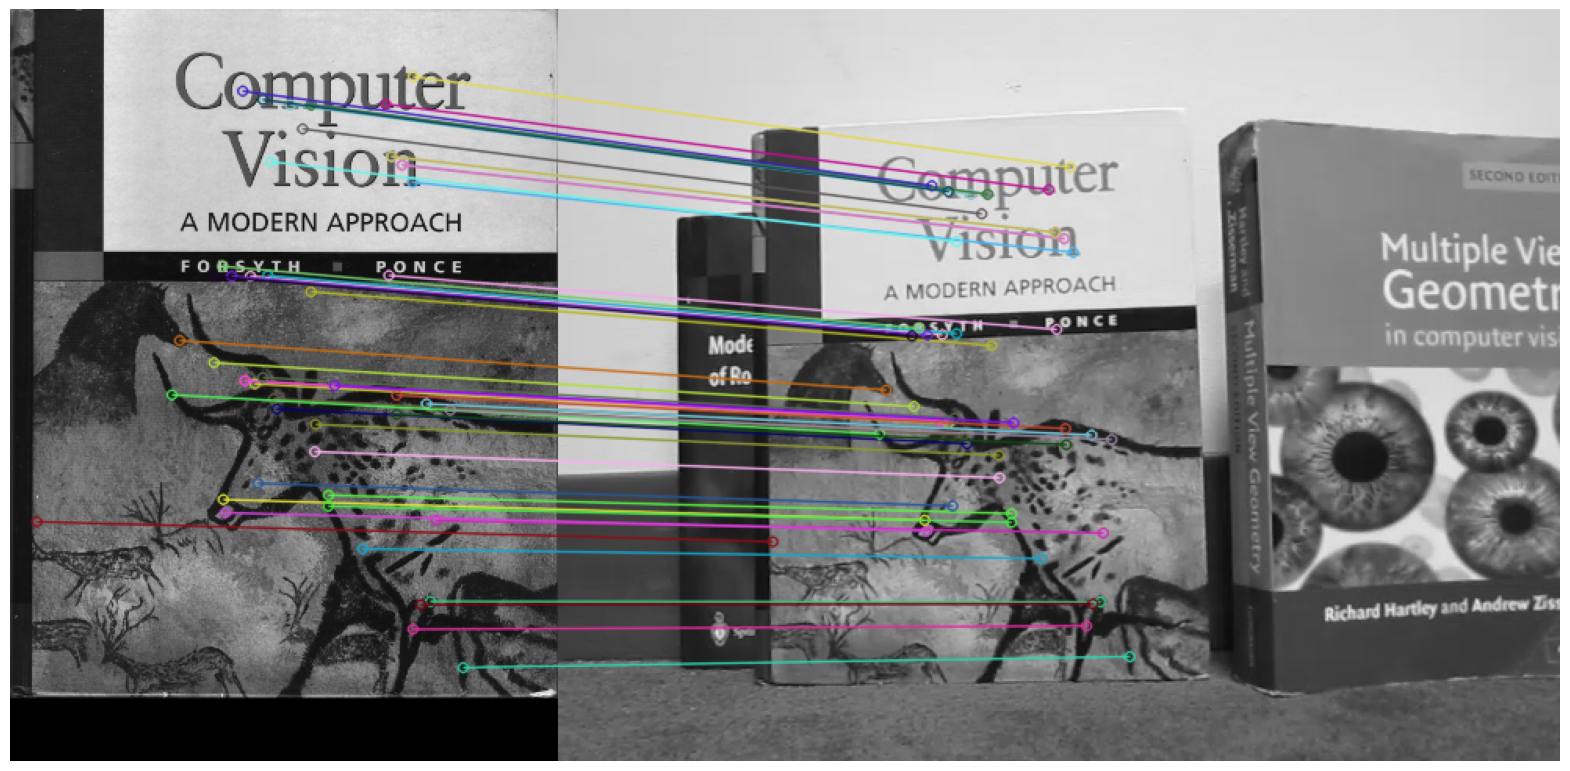

In [50]:
good_matches = good_matches[:50]
img_matches = cv2.drawMatches(book_img, keypoints1, gray_frame, keypoints2, good_matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(20, 10))
plt.imshow(img_matches)
plt.axis('off')
plt.show()

### Homography computing function


In [51]:
def compute_homography(src_pts, dst_pts):

    if len(src_pts) < 4:
        raise ValueError("Need at least 4 points to compute homography")
    # Aih = 0
    # [-x, -y, -1,  0,  0,  0, x * x', y * x', x']
    # [ 0,  0,  0, -x, -y, -1, x * y', y * y', y']


    N = len(src_pts)
    A = []
    for i in range(N):
        (x, y) = src_pts[i]
        (xp, yp) = dst_pts[i]
        A.append([-x, -y, -1,  0,  0,  0, x * xp, y * xp, xp])
        A.append([ 0,  0,  0, -x, -y, -1, x * yp, y * yp, yp])

    A = np.array(A)

    # Solve using SVD: A*h = 0 -> smallest singular value
    U, S, Vt = np.linalg.svd(A)
    h = Vt[-1]  # Solution is last row of V^T
    H = h.reshape(3, 3)

    # Normalize so that H[2,2] == 1
    return H / H[2, 2]
def apply_homography(H, pts):
    pts_homog = np.hstack([pts, np.ones((pts.shape[0], 1))])
    projected = (H @ pts_homog.T).T
    projected /= projected[:, 2][:, np.newaxis]
    return projected[:, :2]


In [52]:
def compute_homography_rnsac(src_pts, dst_pts, threshold=4.0, max_iter=2000) : 
    max_inliers = 0
    best_H = None
    best_inliers_mask = None

    src_pts = np.array(src_pts)
    dst_pts = np.array(dst_pts)

    for _ in range(max_iter):
        idx = np.random.choice(len(src_pts), 4)
        src_sample = src_pts[idx]
        dst_sample = dst_pts[idx]

        try:
            H = compute_homography(src_sample, dst_sample)
        except ValueError:
            continue

        projected = apply_homography(H, src_pts)
        errors = np.linalg.norm(projected - dst_pts, axis=1)
        inlier_mask = errors < threshold
        num_inliers = np.sum(inlier_mask)

        if num_inliers > max_inliers:
            max_inliers = num_inliers
            best_H = H
            best_inliers_mask = inlier_mask
        
    if best_inliers_mask is not None and np.sum(best_inliers_mask) >= 4:
        final_src_pts = src_pts[best_inliers_mask]
        final_dst_pts = dst_pts[best_inliers_mask]
        best_H = compute_homography(final_src_pts, final_dst_pts)

    return best_H, best_inliers_mask        

Homography Matrix:
[[ 7.73175746e-01  2.75722288e-03  1.19569964e+02]
 [-5.11103674e-02  7.78602152e-01  7.74981416e+01]
 [-9.11956120e-05 -7.43420640e-05  1.00000000e+00]]


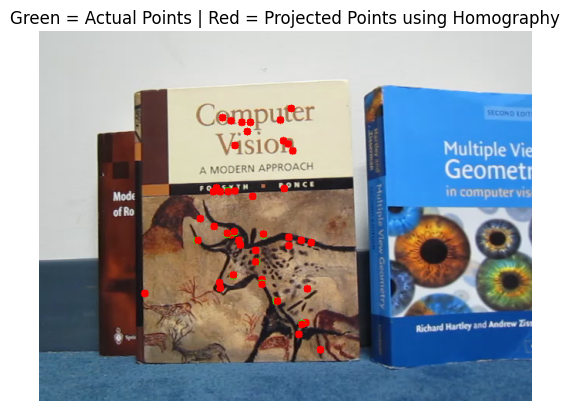

In [53]:

src_pts = np.float32([keypoints1[m.queryIdx].pt for m in good_matches])
dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in good_matches])
H, _=compute_homography_rnsac(src_pts, dst_pts)
print("Homography Matrix:")
print(H)

# projected_pts = apply_homography(H, src_pts)

draw = frame.copy()
# Draw the projected points on the original image
for actual, projected in zip(dst_pts, projected_pts):
    actual = tuple(np.round(actual).astype(int))
    projected = tuple(np.round(projected).astype(int))

    # Draw actual point (green)
    cv2.circle(draw, actual, 5, (0, 255, 0), -1)
    # Draw projected point (red)
    cv2.circle(draw, projected, 5, (0, 0, 255), -1)

plt.imshow(cv2.cvtColor(draw, cv2.COLOR_BGR2RGB))
plt.title("Green = Actual Points | Red = Projected Points using Homography")
plt.axis('off')
plt.show()

### Detcting corners of book in the book video frame using homography


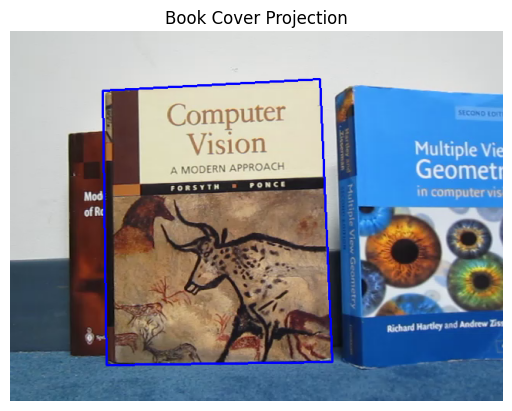

In [54]:
h, w = book_img.shape[:2]


book_corner = np.array([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]], dtype=np.float32)
mapped_corner = apply_homography(H, book_corner)

drawn = frame.copy()

mapped_corner = np.round(mapped_corner).astype(int)
cv2.line(drawn, tuple(mapped_corner[0]), tuple(mapped_corner[1]), (255, 0, 0), 2)
cv2.line(drawn, tuple(mapped_corner[1]), tuple(mapped_corner[2]), (255, 0, 0), 2)
cv2.line(drawn, tuple(mapped_corner[2]), tuple(mapped_corner[3]), (255, 0, 0), 2)
cv2.line(drawn, tuple(mapped_corner[3]), tuple(mapped_corner[0]), (255, 0, 0), 2)


# Convert the image from BGR to RGB for Matplotlib
drawn_rgb = cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB)
# Display the image using Matplotlib
plt.imshow(drawn_rgb)
plt.title("Book Cover Projection")
plt.axis("off")
plt.show()

### cropping video frame using aspect ratio


In [55]:
def crop_video_frame(ar_frame, book_height, book_width):
    # Calculate the aspect ratio of the book
    book_aspect_ratio = book_width / book_height
    
    # Get the dimensions of the AR frame
    ar_height, ar_width = ar_frame.shape[:2]
    
    # Calculate the aspect ratio of the AR frame
    ar_aspect_ratio = ar_width / ar_height
    
    # Determine how to crop based on the aspect ratios
    if ar_aspect_ratio > book_aspect_ratio:
        # AR frame is wider than the book - crop the width
        new_width = int(ar_height * book_aspect_ratio)
        x_offset = (ar_width - new_width) // 2
        cropped_frame = ar_frame[:, x_offset:x_offset + new_width]
    else:
        # AR frame is taller than the book - crop the height
        new_height = int(ar_width / book_aspect_ratio)
        y_offset = (ar_height - new_height) // 2
        cropped_frame = ar_frame[y_offset:y_offset + new_height, :]
    
    return cropped_frame

### showing cropped frame


Cropped AR Frame Shape: (440, 350, 3)


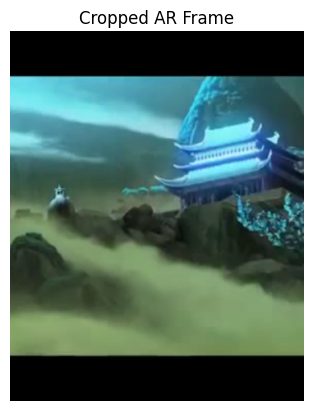

In [56]:
ar_source = cv2.VideoCapture('assignment_2_materials/ar_source.mov')

success, ar_frame = ar_source.read()
if not success:
    print("Failed to read the AR source video.")
    exit()
ar_source.release()
cropped_ar = crop_video_frame(ar_frame, h, w)
cropped_ar = cv2.resize(cropped_ar, (w, h), interpolation=cv2.INTER_LINEAR)

# Show the cropped AR frame
plt.imshow(cropped_ar)
plt.title("Cropped AR Frame")
plt.axis("off")
print("Cropped AR Frame Shape:", cropped_ar.shape)

### overlaying cropped image from video on the book in the video


In [57]:
def overlay(H, cropped_ar, frame, mapped_corner):
    warped_ar = cv2.warpPerspective(cropped_ar, H, (frame.shape[1], frame.shape[0]))
    if len(frame.shape) == 2:
        frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)

    # Create a mask where pixels are valid (don't check brightness; allow black)
    mask = np.zeros(frame.shape[:2], dtype=np.uint8)
    cv2.fillConvexPoly(mask, np.int32(mapped_corner), 255)

    # Use the mask to overwrite only the warped AR pixels
    mask_3ch = cv2.merge([mask, mask, mask])

# Use bitwise operations for compositing
    final_composite = cv2.bitwise_and(frame, cv2.bitwise_not(mask_3ch))
    final_composite += cv2.bitwise_and(warped_ar, mask_3ch)

    return final_composite


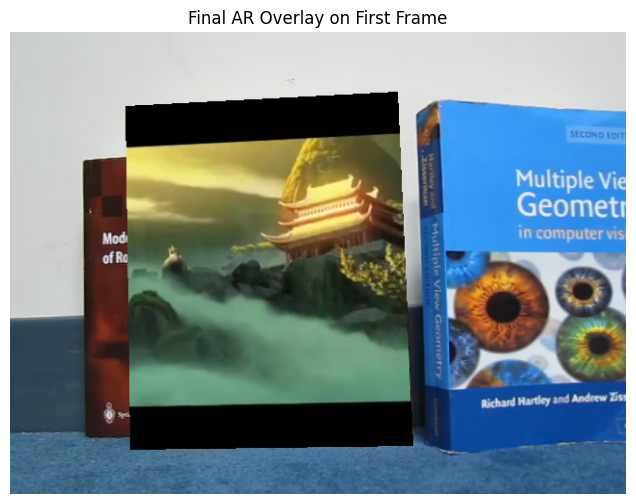

In [58]:
final_overlay = overlay(H, cropped_ar, frame, mapped_corner)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(final_overlay, cv2.COLOR_BGR2RGB))
plt.title("Final AR Overlay on First Frame")
plt.axis("off")
plt.show()

### Creating a whole AR video after trying on first frame


In [59]:
book_cap = cv2.VideoCapture('assignment_2_materials/book.mov')
ar_source = cv2.VideoCapture('assignment_2_materials/ar_source.mov')

frame_width = int(book_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(book_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = book_cap.get(cv2.CAP_PROP_FPS)
total_frames = int(min(book_cap.get(cv2.CAP_PROP_FRAME_COUNT), ar_source.get(cv2.CAP_PROP_FRAME_COUNT)))

out = cv2.VideoWriter('output_AR_video.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

book_img = cv2.imread('assignment_2_materials/cv_cover.jpg')
book_h, book_w = book_img.shape[:2]
sift_detector = cv2.SIFT_create()
keypoints1, descriptors1 = sift_detector.detectAndCompute(book_img, None)
bf = cv2.BFMatcher()


for _ in tqdm.tqdm(range(total_frames), desc="Rendering AR Video..."):
    success1, book_frame = book_cap.read()
    success2, ar_frame = ar_source.read()

    if not success1 or not success2:
        break

    gray_frame = cv2.cvtColor(book_frame, cv2.COLOR_BGR2GRAY)
    kp_frame, des_frame = sift_detector.detectAndCompute(gray_frame, None)
    if des_frame is None or len(des_frame) < 4:
        out.write(book_frame)
        continue

    matches = bf.knnMatch(descriptors1, des_frame, k=2)
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)
    good_matches = sorted(good_matches, key=lambda x: x.distance)
    good_matches = good_matches[:50]
    if len(good_matches) < 4:
        out.write(book_frame)
        continue
    src_pts = np.float32([keypoints1[m.queryIdx].pt for m in good_matches])
    dst_pts = np.float32([kp_frame[m.trainIdx].pt for m in good_matches])
    H,_ = compute_homography_rnsac(src_pts, dst_pts)
    book_corner = np.array([[0, 0], [book_w - 1, 0], [book_w - 1, book_h - 1], [0, book_h - 1]], dtype=np.float32)
    mapped_corner = apply_homography(H, book_corner)
    cropped_ar = crop_video_frame(ar_frame, book_h, book_w)
    cropped_ar = cv2.resize(cropped_ar, (book_w, book_h), interpolation=cv2.INTER_LINEAR)
    final_overlay = overlay(H, cropped_ar, book_frame, mapped_corner)
    out.write(final_overlay)

book_cap.release()
ar_source.release()
out.release()
cv2.destroyAllWindows()
print("AR video saved as 'output_AR_Video.mp4'")

Rendering AR Video...: 100%|██████████| 511/511 [02:29<00:00,  3.41it/s]

AR video saved as 'output_AR_Video.mp4'
